# 0. Импорт и конфигурация

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

RANDOM_STATE = 42

def set_global_seed(seed: int = RANDOM_STATE) -> None:
    np.random.seed(seed)

set_global_seed(RANDOM_STATE)

In [2]:
import resource
soft, hard = resource.getrlimit(resource.RLIMIT_AS)
resource.setrlimit(resource.RLIMIT_AS, (12 * 1024 ** 3, hard))

# 1. Обработка данных

## Шаг 1. Считать данные

В этой работе вы используете тот же датасет, что и в предыдущей работе

In [3]:
Student_ID = 36

In [4]:
datasets = [
    (
        'Give Me Some Credit',
        'https://www.kaggle.com/competitions/GiveMeSomeCredit/overview',
        'SeriousDlqin2yrs'
    ),
    (
        'Porto Seguro’s Safe Driver Prediction',
        'https://www.kaggle.com/competitions/porto-seguro-safe-driver-prediction/overview',
        'target'
    ),
    (
        'Statlog (Shuttle)',
        'https://archive.ics.uci.edu/dataset/148/statlog+shuttle',
        'class'
    ),
    (
        'HTRU2',
        'https://archive.ics.uci.edu/dataset/372/htru2',
        'class'
    ),
    (
        'Bank Marketing',
        'https://archive.ics.uci.edu/dataset/222/bank%2Bmarketing',
        'y'
    ),
]

dataset_id = None if Student_ID is None else Student_ID % len(datasets)
if dataset_id is None:
    print("ОШИБКА! Не указан порядковый номер студента в списке группы.")
else:
    print(f"Информация о датасете '{datasets[dataset_id][0]}' доступна по следующей ссылке: {datasets[dataset_id][1]}")
    print(f"Целевая переменная: {datasets[dataset_id][2]}")

Информация о датасете 'Porto Seguro’s Safe Driver Prediction' доступна по следующей ссылке: https://www.kaggle.com/competitions/porto-seguro-safe-driver-prediction/overview
Целевая переменная: target


Загрузите данные и считайте их в датафрейм

In [5]:
df = pd.read_csv('data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 59 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              595212 non-null  int64  
 1   target          595212 non-null  int64  
 2   ps_ind_01       595212 non-null  int64  
 3   ps_ind_02_cat   595212 non-null  int64  
 4   ps_ind_03       595212 non-null  int64  
 5   ps_ind_04_cat   595212 non-null  int64  
 6   ps_ind_05_cat   595212 non-null  int64  
 7   ps_ind_06_bin   595212 non-null  int64  
 8   ps_ind_07_bin   595212 non-null  int64  
 9   ps_ind_08_bin   595212 non-null  int64  
 10  ps_ind_09_bin   595212 non-null  int64  
 11  ps_ind_10_bin   595212 non-null  int64  
 12  ps_ind_11_bin   595212 non-null  int64  
 13  ps_ind_12_bin   595212 non-null  int64  
 14  ps_ind_13_bin   595212 non-null  int64  
 15  ps_ind_14       595212 non-null  int64  
 16  ps_ind_15       595212 non-null  int64  
 17  ps_ind_16_

## Шаг 2. Обработка данных

В обработке датасета вы имеете (почти) полную свободу (важно в итоге просто побить бейзлайн).

Обработку и подготовку данных можете взять из предыдущей работы

In [6]:
df_base = df.copy()
df_base = df_base.replace(-1, np.nan)
df_base.isna().sum()

id                     0
target                 0
ps_ind_01              0
ps_ind_02_cat        216
ps_ind_03              0
ps_ind_04_cat         83
ps_ind_05_cat       5809
ps_ind_06_bin          0
ps_ind_07_bin          0
ps_ind_08_bin          0
ps_ind_09_bin          0
ps_ind_10_bin          0
ps_ind_11_bin          0
ps_ind_12_bin          0
ps_ind_13_bin          0
ps_ind_14              0
ps_ind_15              0
ps_ind_16_bin          0
ps_ind_17_bin          0
ps_ind_18_bin          0
ps_reg_01              0
ps_reg_02              0
ps_reg_03         107772
ps_car_01_cat        107
ps_car_02_cat          5
ps_car_03_cat     411231
ps_car_04_cat          0
ps_car_05_cat     266551
ps_car_06_cat          0
ps_car_07_cat      11489
ps_car_08_cat          0
ps_car_09_cat        569
ps_car_10_cat          0
ps_car_11_cat          0
ps_car_11              5
ps_car_12              1
ps_car_13              0
ps_car_14          42620
ps_car_15              0
ps_calc_01             0


In [7]:
bin_cols = [col for col in df_base.columns if '_bin' in col]
for col in bin_cols:
    mode_val = df_base[col].mode()[0]
    df_base[col] = df_base[col].fillna(mode_val)

cat_cols = [col for col in df_base.columns if '_cat' in col]
for col in cat_cols:
    mode_val = df_base[col].mode()[0]
    df_base[col] = df_base[col].fillna(mode_val)

numeric_cols = [col for col in df.columns if col not in ['id', 'target'] 
                and '_bin' not in col and '_cat' not in col]
for col in numeric_cols:
    median_val = df_base[col].median()
    df_base[col] = df_base[col].fillna(median_val)

In [8]:
df_base.isna().sum()

id                0
target            0
ps_ind_01         0
ps_ind_02_cat     0
ps_ind_03         0
ps_ind_04_cat     0
ps_ind_05_cat     0
ps_ind_06_bin     0
ps_ind_07_bin     0
ps_ind_08_bin     0
ps_ind_09_bin     0
ps_ind_10_bin     0
ps_ind_11_bin     0
ps_ind_12_bin     0
ps_ind_13_bin     0
ps_ind_14         0
ps_ind_15         0
ps_ind_16_bin     0
ps_ind_17_bin     0
ps_ind_18_bin     0
ps_reg_01         0
ps_reg_02         0
ps_reg_03         0
ps_car_01_cat     0
ps_car_02_cat     0
ps_car_03_cat     0
ps_car_04_cat     0
ps_car_05_cat     0
ps_car_06_cat     0
ps_car_07_cat     0
ps_car_08_cat     0
ps_car_09_cat     0
ps_car_10_cat     0
ps_car_11_cat     0
ps_car_11         0
ps_car_12         0
ps_car_13         0
ps_car_14         0
ps_car_15         0
ps_calc_01        0
ps_calc_02        0
ps_calc_03        0
ps_calc_04        0
ps_calc_05        0
ps_calc_06        0
ps_calc_07        0
ps_calc_08        0
ps_calc_09        0
ps_calc_10        0
ps_calc_11        0


In [9]:
df_processed = df_base.drop_duplicates()

<Axes: >

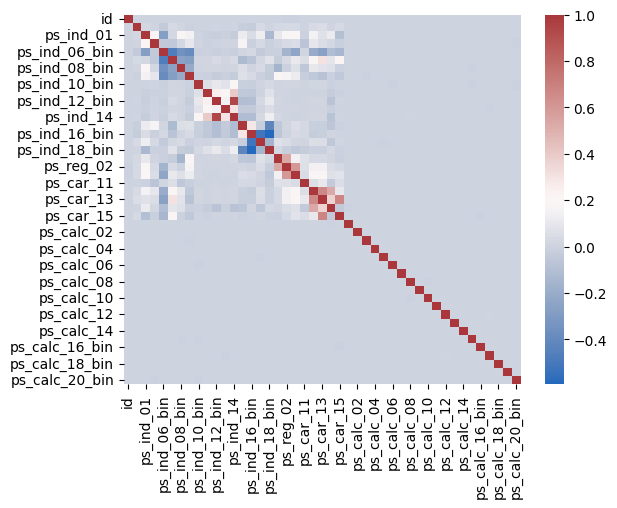

In [10]:
corrs = df_processed[[col for col in df_processed.columns if '_cat' not in col]].corr(method="spearman")
sns.heatmap(corrs, cmap="vlag")

In [11]:
df_processed = df_processed.drop(columns=["ps_ind_14"])
X = df_processed.drop(columns=["target"])
scaler_X = StandardScaler()
X_scaled = pd.DataFrame(scaler_X.fit_transform(X), columns=X.columns, index=X.index)
df_processed = pd.concat([X_scaled, df_processed['target']], axis=1)

## Шаг 3. Разделение на train/val/test

Разделите датафрейм на фичи и на целевую переменную.

In [12]:
X_base, y_base = df_base.drop(columns="target"), df_base["target"]
X_processed, y_processed = df_processed.drop(columns="target"), df_processed["target"]

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(X_base, y_base, test_size=0.2)

X_train_processed, X_test_processed, y_train_processed, y_test_processed = \
    train_test_split(X_processed, y_processed, test_size=0.2)

In [13]:
pca = PCA(n_components=20)
X_pca = pca.fit_transform(X_train_processed)
print(pca.explained_variance_ratio_)

[0.06650928 0.04081237 0.03669421 0.03310736 0.03078105 0.02700377
 0.02471687 0.02393235 0.02126391 0.02108559 0.01915974 0.01850008
 0.01822068 0.0177442  0.01770146 0.01767128 0.01765168 0.01763991
 0.01763457 0.01762521]


In [14]:
rus = RandomUnderSampler(sampling_strategy='auto')

X_train_processed, y_train_processed = rus.fit_resample(X_train_processed, y_train_processed)

print(y_train_processed.value_counts())

X_res_pca = pca.fit_transform(X_train_processed)
print(pca.explained_variance_ratio_)

target
0    17290
1    17290
Name: count, dtype: int64
[0.07245414 0.04066101 0.03819427 0.03339899 0.02945641 0.02897563
 0.02762162 0.02407583 0.02222555 0.02102509 0.0204787  0.01967574
 0.01873277 0.01820015 0.01794948 0.0175752  0.01748742 0.0174067
 0.01730443 0.01718652]


In [15]:
X_train_base, y_train_base =  rus.fit_resample(X_train_base, y_train_base)
print(y_train_base.value_counts())

target
0    17309
1    17309
Name: count, dtype: int64


In [16]:
X_train_processed1, X_val_processed, y_train_processed1, y_val_processed = \
    train_test_split(X_train_processed, y_train_processed, test_size=0.2)

Разделите датафреймы base и processed каждый на выборки train/val/test (запишите их в переменные ниже)

# 2. Классификация

## Шаг 1. Подготовка бейзлайна

На датафрейме `df_base` обучите бейзлайн-модели решающего дерева и случайного леса, используя `sklearn`.

Рекомендуется вычислить метрики, чтобы сравнить их с метриками кастомных моделей. 

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [18]:
dtree_base = DecisionTreeClassifier(
    criterion='gini',
    max_depth=15,
    max_features='sqrt',
    min_samples_split=10
)

dtree_base.fit(X_train_base, y_train_base)
pred_base_dt = dtree_base.predict(X_test_base)
print("DecisionTree")
print(classification_report(y_test_base, pred_base_dt))
print("ROC AUC:", roc_auc_score(y_test_base, pred_base_dt))

DecisionTree
              precision    recall  f1-score   support

           0       0.97      0.57      0.72    114658
           1       0.04      0.50      0.08      4385

    accuracy                           0.57    119043
   macro avg       0.51      0.54      0.40    119043
weighted avg       0.93      0.57      0.70    119043

ROC AUC: 0.5374702036394665


In [19]:
rnd_forest_base = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    n_jobs=-1
)

rnd_forest_base.fit(X_train_base, y_train_base)
pred_base_rf = rnd_forest_base.predict(X_test_base)
print("\nRandomForest")
print(classification_report(y_test_base, pred_base_rf))
print("ROC AUC:", roc_auc_score(y_test_base, pred_base_rf))


RandomForest
              precision    recall  f1-score   support

           0       0.97      0.60      0.74    114658
           1       0.05      0.58      0.10      4385

    accuracy                           0.60    119043
   macro avg       0.51      0.59      0.42    119043
weighted avg       0.94      0.60      0.72    119043

ROC AUC: 0.5866521603197993


## Шаг 2. Обучение кастомных моделей

Импортируйте кастомные модели из .py модулей (рекомедуется держать файлы `models_train.ipynb`, `decision_tree.py` и `random_forest.py` в корне, чтобы не возникло проблем с относительными путями и тестами).

После импорта, обучите модели на датафрейме `df_processed`.

Рекомендуется вычислить метрики, чтобы сравнить их с метриками бейзлайн-моделей.

In [20]:
from decision_tree import CustomDecisionTreeClassifier
from random_forest import CustomRandomForestClassifier
import copy

In [21]:
custom_tree = CustomDecisionTreeClassifier(
    criterion='gini',
    max_depth=15,
    min_samples_split=10,
    max_features='sqrt'
)
custom_tree.fit(X_train_processed1.values, y_train_processed1.values)

pred_custom_tree = custom_tree.predict(X_val_processed.values)
print("Custom Tree")
print(classification_report(y_val_processed, pred_custom_tree))
print("ROC AUC:", roc_auc_score(y_val_processed, pred_custom_tree))

Custom Tree
              precision    recall  f1-score   support

           0       0.55      0.61      0.58      3476
           1       0.56      0.50      0.53      3440

    accuracy                           0.55      6916
   macro avg       0.55      0.55      0.55      6916
weighted avg       0.55      0.55      0.55      6916

ROC AUC: 0.5522031471619343


In [22]:
tree_copy = copy.deepcopy(custom_tree)
tree_copy.ccp(
        X_train_processed1.values, 
        y_train_processed1.values, 
        X_val_processed.values, 
        y_val_processed.values, 
        alpha_crit=0.01
    )
pred = tree_copy.predict(X_val_processed.values)
print("Custom Tree")
print(classification_report(y_val_processed, pred))
print("ROC AUC:", roc_auc_score(y_val_processed, pred))

Custom Tree
              precision    recall  f1-score   support

           0       0.55      0.61      0.58      3476
           1       0.56      0.50      0.53      3440

    accuracy                           0.55      6916
   macro avg       0.55      0.55      0.55      6916
weighted avg       0.55      0.55      0.55      6916

ROC AUC: 0.5524953501752883


In [23]:
custom_forest = CustomRandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    max_features='sqrt'
)
custom_forest.fit(X_train_processed1.values, y_train_processed1.values)

pred_custom_forest = custom_forest.predict(X_val_processed.values)
print("Custom Random Forest")
print(classification_report(y_val_processed, pred_custom_forest))
print("ROC AUC:", roc_auc_score(y_val_processed, pred_custom_forest))

Custom Random Forest
              precision    recall  f1-score   support

           0       0.56      0.67      0.61      3476
           1       0.58      0.46      0.51      3440

    accuracy                           0.57      6916
   macro avg       0.57      0.57      0.56      6916
weighted avg       0.57      0.57      0.56      6916

ROC AUC: 0.5663963189445232


In [24]:
custom_forest_copy = copy.deepcopy(custom_forest)
custom_forest_copy.prune(
        X_train_processed1.values, 
        y_train_processed1.values, 
        X_val_processed.values, 
        y_val_processed.values, 
        alpha_crit=0.01,
        max_prune_steps=10
    )
pred_forest = custom_forest_copy.predict(X_val_processed.values)
print("Custom Tree")
print(classification_report(y_val_processed, pred_forest))
print("ROC AUC:", roc_auc_score(y_val_processed, pred_forest))

Custom Tree
              precision    recall  f1-score   support

           0       0.56      0.68      0.61      3476
           1       0.58      0.46      0.52      3440

    accuracy                           0.57      6916
   macro avg       0.57      0.57      0.56      6916
weighted avg       0.57      0.57      0.56      6916

ROC AUC: 0.5687023309337116


## Шаг 3. Финал

После обучения бейзлайна и кастомных моделей, подготовьте файлы `baseline_solution.csv` и `solution.csv`, аналогично файлу `example.csv`. Для этого выполните предсказание на тестовой выборке `X_processed_test`.

Также подготовьте файл `labels.csv` с метками классов из вашей тестовой выборки `y_processed_test`.

In [25]:
final_predictions = custom_forest.predict(X_test_processed.values)

sklearn_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    max_features="sqrt",
    n_jobs=-1
)
sklearn_final.fit(X_train_processed.values, y_train_processed.values)
sklearn_pred = sklearn_final.predict(X_test_processed.values)

In [26]:
pd.DataFrame({'target': sklearn_pred}).to_csv('baseline_solution.csv', index=False)
pd.DataFrame({'target': final_predictions}).to_csv('solution.csv', index=False)
pd.DataFrame({'target': y_test_processed.values}).to_csv('labels.csv', index=False)

# Шаг 4. Градиентный бустинг

In [27]:
from grad_boosting import CustomGradientBoostingClassifier

In [28]:
custom_gbm = CustomGradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    min_samples_split=10,
    max_features='sqrt',
    n_jobs=-1
)

custom_gbm.fit(X_train_processed1.values, y_train_processed1.values)

pred_custom_gbm = custom_gbm.predict(X_val_processed.values)
pred_proba_custom_gbm = custom_gbm.predict_proba(X_val_processed.values)[:, 1]

print("Custom Gradient Boosting")
print(classification_report(y_val_processed, pred_custom_gbm))
print("ROC AUC:", roc_auc_score(y_val_processed, pred_proba_custom_gbm))

Tree 1/100 | Passed: 0.0с | Left: 0.9с


Tree 2/100 | Passed: 3.9с | Left: 189.9с
Tree 3/100 | Passed: 8.5с | Left: 273.3с
Tree 4/100 | Passed: 14.8с | Left: 354.6с
Tree 5/100 | Passed: 29.9с | Left: 567.7с
Tree 6/100 | Passed: 32.3с | Left: 505.5с
Tree 7/100 | Passed: 40.3с | Left: 535.6с
Tree 8/100 | Passed: 49.3с | Left: 566.6с
Tree 9/100 | Passed: 58.7с | Left: 593.7с
Tree 10/100 | Passed: 66.7с | Left: 600.0с
Tree 11/100 | Passed: 74.3с | Left: 601.3с
Tree 12/100 | Passed: 83.3с | Left: 610.7с
Tree 13/100 | Passed: 104.6с | Left: 699.7с
Tree 14/100 | Passed: 107.9с | Left: 662.8с
Tree 15/100 | Passed: 114.2с | Left: 646.9с
Tree 16/100 | Passed: 115.6с | Left: 607.0с
Tree 17/100 | Passed: 126.3с | Left: 616.5с
Tree 18/100 | Passed: 135.0с | Left: 615.2с
Tree 19/100 | Passed: 152.4с | Left: 649.8с
Tree 20/100 | Passed: 160.8с | Left: 643.3с
Tree 21/100 | Passed: 167.2с | Left: 629.2с
Tree 22/100 | Passed: 170.6с | Left: 604.9с
Tree 23/100 | Passed: 183.8с | Left: 615.3с
Tree 24/100 | Passed: 191.8с | Left: 607.3с
Tree 25/1